<a href="https://colab.research.google.com/github/sidneyppratt-svg/quant-regime-detector/blob/main/regime_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip install yfinance scikit-learn pandas numpy matplotlib seaborn -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Download 10 years of real market data for 4 asset classes
# SPY = US Stock Market
# AGG = US Bonds
# HYG = High Yield Credit (riskier bonds)
# GLD = Gold (commodity)

print("Downloading market data... this may take 30 seconds...")

tickers = ['SPY', 'AGG', 'HYG', 'GLD']
prices = yf.download(tickers, start='2014-01-01', end='2026-09-18', auto_adjust=True)['Close']
prices = prices.dropna()

print(f"✅ Data downloaded successfully!")
print(f"📅 Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"📊 Total trading days: {len(prices)}")
print(f"\nFirst few rows of data:")
print(prices.head())

[*********************100%***********************]  4 of 4 completed

✅ Data downloaded successfully!
📅 Date range: 2014-01-02 to 2026-09-17
📊 Total trading days: 3196

First few rows of data:
Ticker            AGG         GLD        HYG         SPY
Date                                                    
2014-01-02  75.132599  118.000000  47.260651  148.198486
2014-01-03  75.160805  119.290001  47.245438  148.174210
2014-01-06  75.259583  119.500000  47.347042  147.744751
2014-01-07  75.294853  118.820000  47.347042  148.652145
2014-01-08  75.069115  118.120003  47.316570  148.684555


In [9]:
# Calculate daily returns for each asset
# (how much each asset went up or down each day in percentage)
returns = prices.pct_change().dropna()

# Build smoothed signals (21-day rolling average)
# This smooths out the day-to-day noise so the AI sees trends
smooth = returns.rolling(21).mean().dropna()

print("✅ Signals built successfully!")
print(f"📊 Working with {len(smooth)} days of signal data")
print(f"\nAverage daily returns per asset:")
print((returns.mean() * 252 * 100).round(2).to_frame("Annualized Return %"))

✅ Signals built successfully!
📊 Working with 3175 days of signal data

Average daily returns per asset:
        Annualized Return %
Ticker                     
AGG                    2.09
GLD                   10.90
HYG                    4.34
SPY                   14.40


In [10]:
from sklearn.mixture import GaussianMixture

# Train the AI regime detector
# It looks at all 4 assets together and sorts every day into
# either RISK-ON (markets calm) or RISK-OFF (markets stressed)

print("Training AI model...")

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
smooth['regime'] = gmm.fit_predict(smooth[['SPY', 'AGG', 'HYG', 'GLD']])

# Label each regime based on which one had better stock returns
# The regime where SPY did better = RISK-ON
# The regime where SPY did worse  = RISK-OFF
equity_by_regime = smooth.groupby('regime')['SPY'].mean()
risk_on  = int(equity_by_regime.idxmax())
risk_off = int(equity_by_regime.idxmin())

smooth['label'] = smooth['regime'].map({
    risk_on:  'RISK-ON  ✅',
    risk_off: 'RISK-OFF ⚠️'
})

# Summary of what the AI found
summary = smooth.groupby('label')[['SPY','AGG','HYG','GLD']].mean() * 252 * 100
print("\n✅ AI model trained successfully!")
print("\n📊 Average annualized returns per regime (%):")
print(summary.round(2))

# How often is the market in each regime?
counts = smooth['label'].value_counts(normalize=True) * 100
print(f"\n⏱️ Time spent in each regime:")
for label, pct in counts.items():
    print(f"   {label}: {pct:.1f}% of the time")

Training AI model...

✅ AI model trained successfully!

📊 Average annualized returns per regime (%):
Ticker          SPY   AGG    HYG    GLD
label                                  
RISK-OFF ⚠️ -114.56 -0.32 -69.13   9.97
RISK-ON  ✅    16.23  2.12   5.33  11.02

⏱️ Time spent in each regime:
   RISK-ON  ✅: 98.7% of the time
   RISK-OFF ⚠️: 1.3% of the time


In [11]:
# Now we test: if you followed the AI's signals historically,
# how much money would you have made vs just holding SPY forever?

spy_returns = returns['SPY'].loc[smooth.index]
signal = (smooth['label'] == 'RISK-ON  ✅').astype(int)

# Strategy: invest in SPY on RISK-ON days, sit in cash on RISK-OFF days
strategy_returns = signal.shift(1) * spy_returns
strategy_returns = strategy_returns.dropna()
bh_returns = spy_returns.loc[strategy_returns.index]

# Calculate performance metrics
def get_metrics(r):
    cum     = (1 + r).cumprod()
    total   = cum.iloc[-1] - 1
    ann_ret = (1 + total) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    max_dd  = (cum / cum.cummax() - 1).min()
    win_rt  = (r > 0).mean()
    return cum, {
        'Total Return':      f'{total:.1%}',
        'Annualized Return': f'{ann_ret:.1%}',
        'Annualized Vol':    f'{ann_vol:.1%}',
        'Sharpe Ratio':      f'{sharpe:.2f}',
        'Max Drawdown':      f'{max_dd:.1%}',
        'Win Rate':          f'{win_rt:.1%}',
    }

cum_strat, metrics_strat = get_metrics(strategy_returns)
cum_bh,    metrics_bh    = get_metrics(bh_returns)

print("✅ Backtest complete!\n")
print(f"{'Metric':<22} {'AI Strategy':>14} {'Buy & Hold':>14}")
print("-" * 52)
for key in metrics_strat:
    print(f"{key:<22} {metrics_strat[key]:>14} {metrics_bh[key]:>14}")

✅ Backtest complete!

Metric                    AI Strategy     Buy & Hold
----------------------------------------------------
Total Return                   441.9%         440.4%
Annualized Return               14.4%          14.3%
Annualized Vol                  15.5%          17.1%
Sharpe Ratio                     0.93           0.84
Max Drawdown                   -24.0%         -33.7%
Win Rate                        54.4%          55.0%


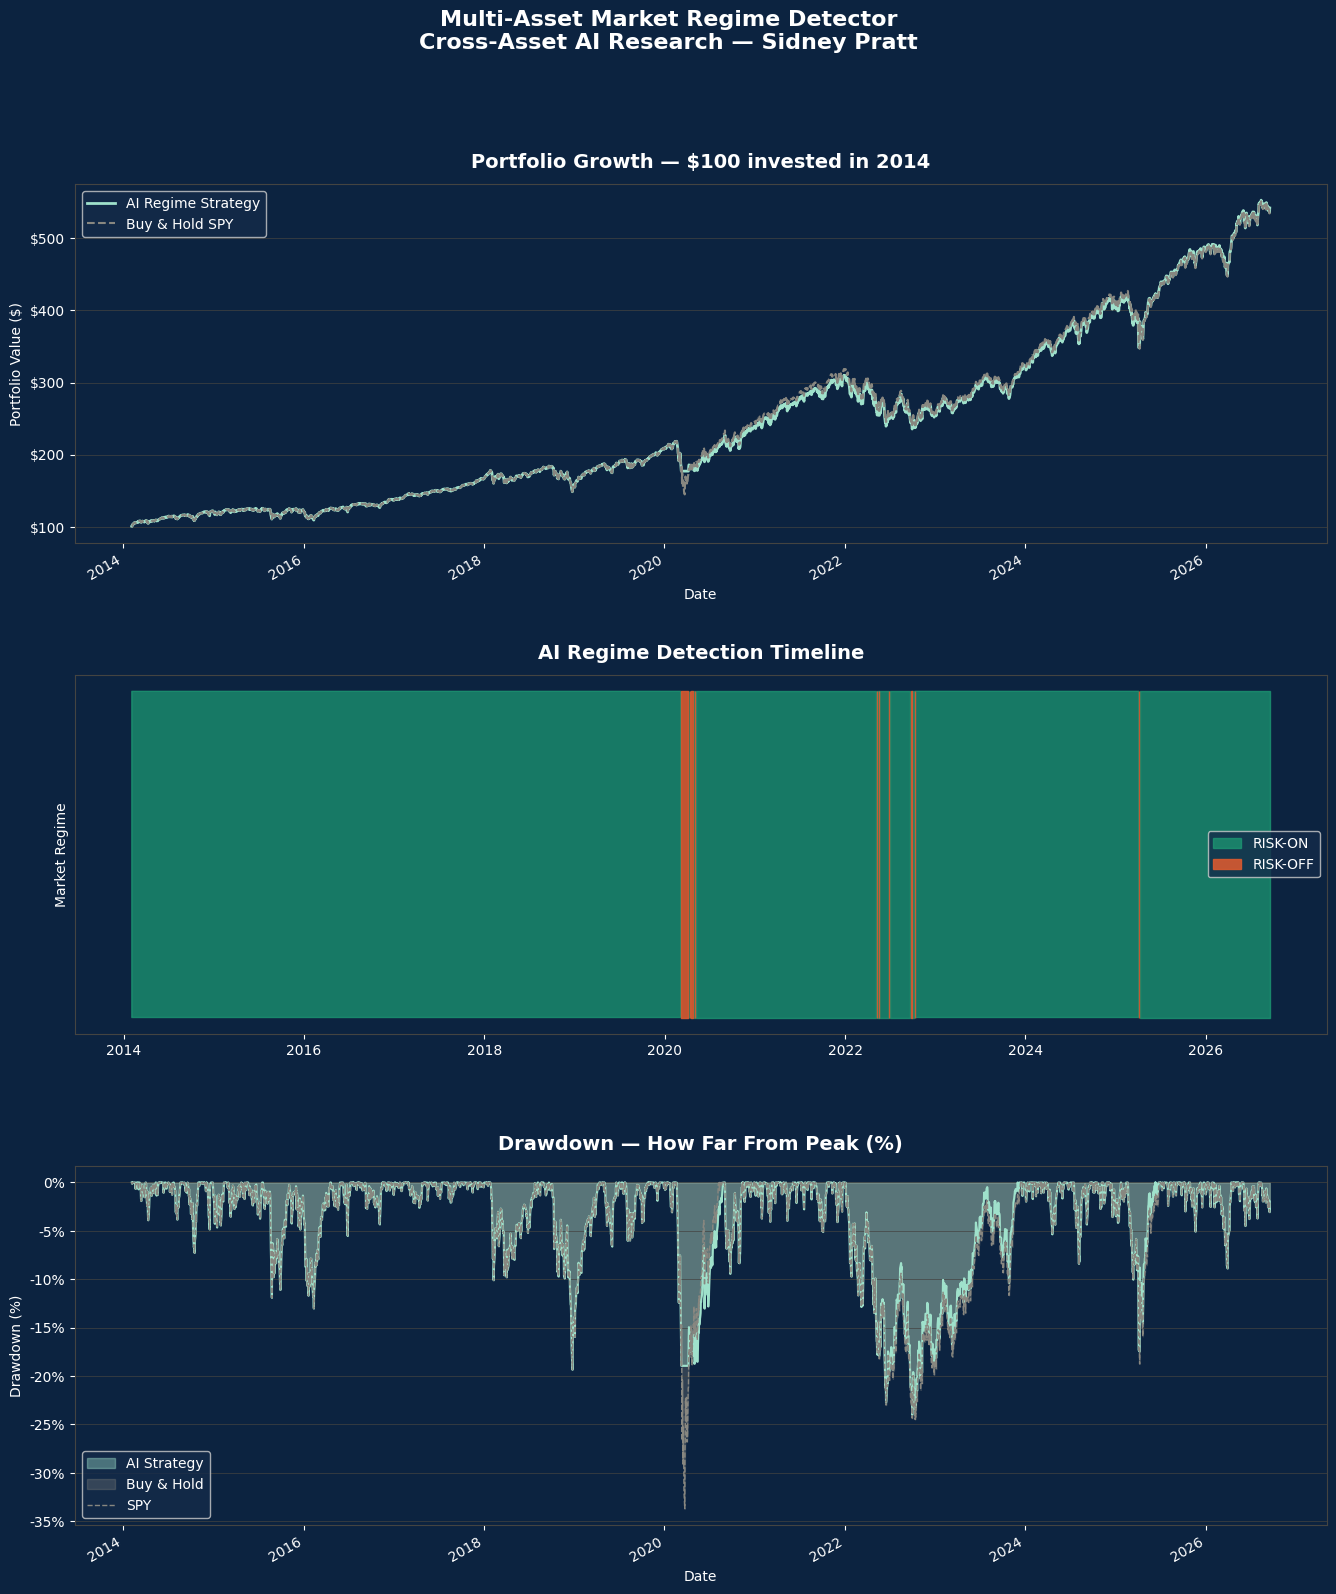

✅ Charts saved successfully!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.patch.set_facecolor('#0C2340')

for ax in axes:
    ax.set_facecolor('#0C2340')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444441')

# ── Chart 1: Equity Curve ──────────────────────────────────────
ax1 = axes[0]
(cum_strat * 100).plot(ax=ax1, color='#9FE1CB', linewidth=2,
                        label='AI Regime Strategy')
(cum_bh * 100).plot(ax=ax1, color='#888780', linewidth=1.5,
                     linestyle='--', label='Buy & Hold SPY')
ax1.set_title('Portfolio Growth — $100 invested in 2014',
               color='white', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Portfolio Value ($)', color='white')
ax1.legend(facecolor='#142B4A', labelcolor='white', fontsize=10)
ax1.grid(axis='y', color='#444441', linewidth=0.5)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

# ── Chart 2: Regime Timeline ───────────────────────────────────
ax2 = axes[1]
dates = smooth.index
risk_on_mask  = smooth['label'] == 'RISK-ON  ✅'
risk_off_mask = smooth['label'] == 'RISK-OFF ⚠️'

ax2.fill_between(dates, 0, 1,
                  where=risk_on_mask,
                  color='#1D9E75', alpha=0.7, label='RISK-ON')
ax2.fill_between(dates, 0, 1,
                  where=risk_off_mask,
                  color='#D85A30', alpha=0.9, label='RISK-OFF')
ax2.set_title('AI Regime Detection Timeline',
               color='white', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Market Regime', color='white')
ax2.set_yticks([])
ax2.legend(facecolor='#142B4A', labelcolor='white', fontsize=10)
ax2.grid(False)

# ── Chart 3: Drawdown ──────────────────────────────────────────
ax3 = axes[2]
dd_strat = (cum_strat / cum_strat.cummax() - 1) * 100
dd_bh    = (cum_bh    / cum_bh.cummax()    - 1) * 100

ax3.fill_between(dd_strat.index, dd_strat, 0,
                  color='#9FE1CB', alpha=0.4, label='AI Strategy')
ax3.fill_between(dd_bh.index, dd_bh, 0,
                  color='#888780', alpha=0.3, label='Buy & Hold')
dd_strat.plot(ax=ax3, color='#9FE1CB', linewidth=1.5)
dd_bh.plot(ax=ax3,    color='#888780', linewidth=1,   linestyle='--')
ax3.set_title('Drawdown — How Far From Peak (%)',
               color='white', fontsize=14, fontweight='bold', pad=12)
ax3.set_ylabel('Drawdown (%)', color='white')
ax3.legend(facecolor='#142B4A', labelcolor='white', fontsize=10)
ax3.grid(axis='y', color='#444441', linewidth=0.5)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── Title block ────────────────────────────────────────────────
fig.suptitle(
    'Multi-Asset Market Regime Detector\nCross-Asset AI Research — Sidney Pratt',
    color='white', fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout(pad=3.0)
plt.savefig('regime_detector_charts.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0C2340')
plt.show()
print("✅ Charts saved successfully!")

In [13]:
from datetime import datetime

# Get the most recent 30 days of data
recent = smooth.tail(30).copy()

# Get today's signal
latest_date = recent.index[-1].strftime('%B %d, %Y')
latest_label = recent['label'].iloc[-1]
latest_spy = returns['SPY'].tail(30).sum() * 100
latest_hyg = returns['HYG'].tail(30).sum() * 100
latest_agg = returns['AGG'].tail(30).sum() * 100
latest_gld = returns['GLD'].tail(30).sum() * 100

print("=" * 50)
print("   LIVE MARKET REGIME SIGNAL")
print("=" * 50)
print(f"\n📅 As of: {latest_date}")
print(f"\n🤖 AI Signal: {latest_label}")
print(f"\n📊 Last 30 days performance:")
print(f"   SPY (Stocks) : {latest_spy:+.2f}%")
print(f"   AGG (Bonds)  : {latest_agg:+.2f}%")
print(f"   HYG (Credit) : {latest_hyg:+.2f}%")
print(f"   GLD (Gold)   : {latest_gld:+.2f}%")

# Recommendation
print("\n" + "=" * 50)
if "RISK-ON" in latest_label:
    print("✅ RECOMMENDATION: Markets are calm.")
    print("   Model suggests staying INVESTED in equities.")
else:
    print("⚠️  RECOMMENDATION: Market stress detected.")
    print("   Model suggests moving to CASH.")
print("=" * 50)

   LIVE MARKET REGIME SIGNAL

📅 As of: September 17, 2026

🤖 AI Signal: RISK-ON  ✅

📊 Last 30 days performance:
   SPY (Stocks) : -0.89%
   AGG (Bonds)  : -1.07%
   HYG (Credit) : -0.46%
   GLD (Gold)   : +2.58%

✅ RECOMMENDATION: Markets are calm.
   Model suggests staying INVESTED in equities.


# New Section

# New Section